In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader,Dataset
import matplotlib.pyplot as plt

import numpy as np

In [2]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
epochs = 10
learning_rate = 1e-4
weight_decay = 0.1
batch_size = 64
latent_dim = 64

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # To [-1,1]
])

In [5]:
## building dataset
#  32x32 colour images
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

In [6]:
## creating train and test loader
train_loader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(testset, batch_size=64, shuffle=True, num_workers=2)

In [7]:
for images,labels in train_loader:
  break

Text(0.5, 1.0, 'Label:ship')

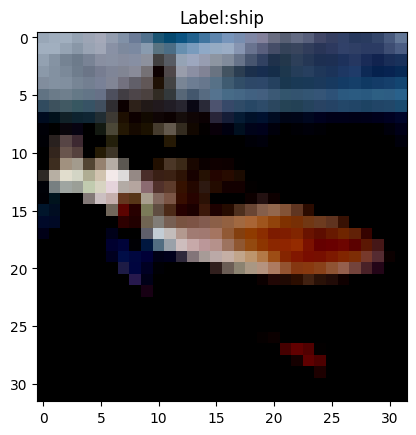

In [8]:
plt.imshow(images[0].permute(1, 2, 0)) # it want (32,32,3) shape
plt.title(f"Label:{classes[labels[0]]}")

In [9]:
import torch.nn.functional as f

In [10]:
class VariationalEncoder(nn.Module):
  def __init__(self,latent_dim=128):
    super().__init__()
    # ENCODER : lImage -> latent_dim
    self.enc_conv1 = nn.Conv2d(3,32,4,padding=1,stride=2) ## 16*16
    self.enc_conv2 = nn.Conv2d(32,64,4,padding=1,stride=2) # 8*8
    self.enc_fc_mu = nn.Linear(64*8*8,latent_dim)
    self.enc_fc_var = nn.Linear(64*8*8,latent_dim)
    # DECODER: latent_dim -> Image 3x32x32
    self.dec_fc = nn.Linear(latent_dim, 64 * 8 * 8)
    self.dec_deconv1 = nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1) # 16x16
    self.dec_deconv2 = nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1)   # 32x32

  def encoder(self,X):
    h1 = f.relu(self.enc_conv1(X))
    h2 = f.relu(self.enc_conv2(h1))
    h2 = h2.view(h2.size(0),-1) # flatten
    mu = self.enc_fc_mu(h2)
    var = self.enc_fc_var(h2)
    return mu , var

  def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)  # ε ~ N(0,1)
        return mu + eps * std

  def decoder(self, z):
        h = f.relu(self.dec_fc(z))
        h = h.view(-1, 64, 8, 8)  # Reshape to feature map
        h = f.relu(self.dec_deconv1(h))
        recon = torch.sigmoid(self.dec_deconv2(h))  # [0,1] output
        return recon

  def forward(self,X):
    mu,logvar = self.encoder(X)
    z = self.reparameterize(mu,logvar)
    return self.decoder(z) , mu , logvar

In [15]:
def loss_fn(recon, x, mu, logvar):
    return f.mse_loss(recon, x, reduction='sum') - 0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

In [12]:
# Training
model = VariationalEncoder(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [13]:
model

VariationalEncoder(
  (enc_conv1): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc_conv2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc_fc_mu): Linear(in_features=4096, out_features=64, bias=True)
  (enc_fc_var): Linear(in_features=4096, out_features=64, bias=True)
  (dec_fc): Linear(in_features=64, out_features=4096, bias=True)
  (dec_deconv1): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (dec_deconv2): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
)

In [16]:
model.train()
num_epochs = 30
for epoch in range(num_epochs):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)

        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_fn(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

        if batch_idx % 200 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item()/len(data):.2f}')

    avg_loss = train_loss / len(train_loader.dataset)
    print(f'==== Epoch {epoch+1} Average Loss: {avg_loss:.2f} ====')

Epoch 1/30, Batch 0/782, Loss: 1670.65
Epoch 1/30, Batch 200/782, Loss: 712.27
Epoch 1/30, Batch 400/782, Loss: 736.31
Epoch 1/30, Batch 600/782, Loss: 633.11
==== Epoch 1 Average Loss: 780.92 ====
Epoch 2/30, Batch 0/782, Loss: 659.75
Epoch 2/30, Batch 200/782, Loss: 662.86
Epoch 2/30, Batch 400/782, Loss: 560.84
Epoch 2/30, Batch 600/782, Loss: 643.05
==== Epoch 2 Average Loss: 628.64 ====
Epoch 3/30, Batch 0/782, Loss: 638.48
Epoch 3/30, Batch 200/782, Loss: 593.82
Epoch 3/30, Batch 400/782, Loss: 606.79
Epoch 3/30, Batch 600/782, Loss: 589.71
==== Epoch 3 Average Loss: 604.48 ====
Epoch 4/30, Batch 0/782, Loss: 587.18
Epoch 4/30, Batch 200/782, Loss: 560.72
Epoch 4/30, Batch 400/782, Loss: 593.67
Epoch 4/30, Batch 600/782, Loss: 544.36
==== Epoch 4 Average Loss: 592.14 ====
Epoch 5/30, Batch 0/782, Loss: 592.94
Epoch 5/30, Batch 200/782, Loss: 525.94
Epoch 5/30, Batch 400/782, Loss: 634.88
Epoch 5/30, Batch 600/782, Loss: 541.27
==== Epoch 5 Average Loss: 585.26 ====
Epoch 6/30, Ba